<a href="https://colab.research.google.com/github/J-Aamir/FineTuned-Finance-Models-Evaluation-using-Judge/blob/main/Qwen2.5-7B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# NOTEBOOK 2: Fine-tune Qwen2.5-7B-Instruct
# Financial QA | finance-alpaca dataset
# OOM-SAFE VERSION — tested for Colab T4 (16GB VRAM)
# Checkpoints saved every 300 steps to Google Drive
# ============================================================

# ── CELL 1: Check GPU ────────────────────────────────────────
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

# ── CELL 2: Install dependencies ─────────────────────────────
# After this cell, Runtime → Restart session, then run from Cell 3
get_ipython().system('pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"')
get_ipython().system('pip install -q --no-deps trl peft accelerate bitsandbytes')
get_ipython().system('pip install -q datasets transformers')







Tue Apr 28 07:28:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# ── CELL 3: Mount Google Drive ───────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
import os, json, torch

SAVE_DIR       = "/content/drive/MyDrive/assignment3/qwen25_7b_financial"
CKPT_DIR       = "/content/drive/MyDrive/assignment3/qwen25_7b_financial/checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)
print(f"✅ Save dir:       {SAVE_DIR}")
print(f"✅ Checkpoint dir: {CKPT_DIR}")

# ── CELL 4: Load model — OOM-SAFE 4-bit NF4 ──────────────────
# This is the same fix used for Mistral:
# 4-bit NF4 quantization drops VRAM from ~28GB → ~5.5GB on T4

from unsloth import FastLanguageModel

MAX_SEQ_LENGTH = 1024   # Reduced from 2048 — saves significant VRAM
LOAD_IN_4BIT   = True   # NF4 quantization — REQUIRED for T4

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = "unsloth/Qwen2.5-7B-Instruct-bnb-4bit",
    max_seq_length = MAX_SEQ_LENGTH,
    dtype          = None,          # auto-detect: fp16 on T4
    load_in_4bit   = LOAD_IN_4BIT,
)
print("✅ Qwen2.5-7B loaded in 4-bit NF4")
print(f"   GPU memory used: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# ── CELL 5: Attach LoRA adapters ─────────────────────────────
model = FastLanguageModel.get_peft_model(
    model,
    r              = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha     = 32,
    lora_dropout   = 0.05,
    bias           = "none",
    use_gradient_checkpointing = "unsloth",   # saves ~30% VRAM
    random_state   = 42,
)
print("✅ LoRA adapters attached")
model.print_trainable_parameters()


Mounted at /content/drive
✅ Save dir:       /content/drive/MyDrive/assignment3/qwen25_7b_financial
✅ Checkpoint dir: /content/drive/MyDrive/assignment3/qwen25_7b_financial/checkpoints
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.55G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

unsloth/Qwen2.5-7B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


✅ Qwen2.5-7B loaded in 4-bit NF4
   GPU memory used: 5.59 GB


Unsloth 2026.4.8 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


✅ LoRA adapters attached
trainable params: 40,370,176 || all params: 7,655,986,688 || trainable%: 0.5273


In [ ]:
# ── CELL 6: Load and prepare finance-alpaca dataset ──────────
from datasets import load_dataset

dataset = load_dataset("gbharti/finance-alpaca", split="train")
print(f"Raw dataset size: {len(dataset)}")

# ── CELL 7: Format prompts (Qwen2.5 chat template) ───────────
SYSTEM_PROMPT = (
    "You are a knowledgeable financial assistant. "
    "Answer financial questions accurately, clearly, and concisely."
)

def format_prompt_qwen(examples):
    instructions = examples["instruction"]
    inputs       = examples["input"]
    outputs      = examples["output"]
    texts = []
    for inst, inp, out in zip(instructions, inputs, outputs):
        context  = inp.strip() if inp and inp.strip() else ""
        user_msg = f"{inst}\n\nContext: {context}" if context else inst
        messages = [
            {"role": "system",    "content": SYSTEM_PROMPT},
            {"role": "user",      "content": user_msg},
            {"role": "assistant", "content": out},
        ]
        text = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False
        )
        texts.append(text)
    return {"text": texts}

dataset = dataset.map(format_prompt_qwen, batched=True)

# Filter: keep samples between 100–800 tokens
# NOTE: We use 100 (not 200 like Mistral) to keep more samples
#       and 800 (not 2048) to match our reduced MAX_SEQ_LENGTH
def filter_samples(example):
    token_count = len(tokenizer(example["text"])["input_ids"])
    return 100 < token_count < 800

dataset = dataset.filter(filter_samples)
print(f"After filtering: {len(dataset)} samples")

# Use 8000 samples — more than Mistral's 4000 for better training
TRAIN_SIZE = 8000
dataset = dataset.shuffle(seed=42).select(range(min(TRAIN_SIZE, len(dataset))))
print(f"✅ Training on {len(dataset)} samples")
print(f"   (Mistral used 4,000 — Qwen uses 8,000 for better convergence)")

# ── CELL 8: Trainer — OOM-SAFE + Checkpoint every 300 steps ──
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

trainer = SFTTrainer(
    model              = model,
    tokenizer          = tokenizer,
    train_dataset      = dataset,
    dataset_text_field = "text",
    max_seq_length     = MAX_SEQ_LENGTH,
    dataset_num_proc   = 2,
    packing            = False,
    args = TrainingArguments(
        # ── Batch settings (OOM-safe) ──────────────────────
        per_device_train_batch_size = 1,    # same as your Mistral fix
        gradient_accumulation_steps = 8,    # effective batch = 8
        max_grad_norm               = 0.3,  # prevents gradient explosions

        # ── Training duration ──────────────────────────────
        num_train_epochs            = 2,    # 2 epochs vs Mistral's 1
        warmup_steps                = 100,
        learning_rate               = 2e-4,

        # ── Precision (T4 uses fp16) ───────────────────────
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),

        # ── Optimizer (8-bit saves VRAM) ───────────────────
        optim          = "adamw_8bit",
        weight_decay   = 0.01,
        lr_scheduler_type = "cosine",

        # ── Logging ────────────────────────────────────────
        logging_steps  = 25,

        # ── Checkpoint saving every 300 steps ──────────────
        # This means if your GPU session dies, you resume
        # from the last checkpoint, not from scratch
        save_strategy       = "steps",
        save_steps          = 300,
        save_total_limit    = 3,        # keep last 3 checkpoints on Drive
        output_dir          = CKPT_DIR, # saves directly to Google Drive

        seed       = 42,
        report_to  = "none",
    ),
)
print("✅ Trainer configured")
print(f"   Effective batch size: {1 * 8} (1 per device × 8 grad accum)")
print(f"   Checkpoints: every 300 steps → {CKPT_DIR}")


README.md:   0%|          | 0.00/831 [00:00<?, ?B/s]

Cleaned_date.json:   0%|          | 0.00/42.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/68912 [00:00<?, ? examples/s]

Raw dataset size: 68912


Map:   0%|          | 0/68912 [00:00<?, ? examples/s]

Filter:   0%|          | 0/68912 [00:00<?, ? examples/s]

After filtering: 38820 samples
✅ Training on 8000 samples
   (Mistral used 4,000 — Qwen uses 8,000 for better convergence)


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/8000 [00:00<?, ? examples/s]

✅ Trainer configured
   Effective batch size: 8 (1 per device × 8 grad accum)
   Checkpoints: every 300 steps → /content/drive/MyDrive/assignment3/qwen25_7b_financial/checkpoints


In [ ]:
# ── CELL 9: Train (resumes from checkpoint if one exists) ─────
import os

# Check if a checkpoint already exists (so you can resume)
existing_ckpts = [
    d for d in os.listdir(CKPT_DIR)
    if d.startswith("checkpoint-")
] if os.path.exists(CKPT_DIR) else []

if existing_ckpts:
    latest = sorted(existing_ckpts, key=lambda x: int(x.split("-")[1]))[-1]
    resume_path = os.path.join(CKPT_DIR, latest)
    print(f"🔄 Resuming from checkpoint: {resume_path}")
else:
    resume_path = None
    print("🚀 No checkpoint found — starting from scratch")

print("Starting training...")
trainer_stats = trainer.train(resume_from_checkpoint=resume_path)
print(f"\n✅ Training complete!")
print(f"   Final loss: {trainer_stats.training_loss:.4f}")

# ── CELL 10: Save final model to Google Drive ─────────────────
print("💾 Saving final model to Drive...")
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

stats = {
    "model"         : "Qwen2.5-7B-Instruct",
    "dataset"       : "finance-alpaca",
    "train_samples" : len(dataset),
    "final_loss"    : trainer_stats.training_loss,
    "epochs"        : 2,
    "max_seq_length": MAX_SEQ_LENGTH,
    "lora_rank"     : 16,
    "batch_size"    : "1 per device × 8 grad accum = 8 effective",
}
with open(f"{SAVE_DIR}/training_stats.json", "w") as f:
    json.dump(stats, f, indent=2)

print(f"✅ Model saved to {SAVE_DIR}")
print(f"✅ Training stats saved")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🚀 No checkpoint found — starting from scratch
Starting training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 8,000 | Num Epochs = 2 | Total steps = 2,000
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 40,370,176 of 7,655,986,688 (0.53% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
25,2.575651
50,1.663711
75,1.648495
100,1.624548
125,1.680937
150,1.613278
175,1.678050
200,1.669821
225,1.580691
250,1.617527


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/assignment3/qwen25_7b_financial/checkpoints/checkpoint-300/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/assignment3/qwen25_7b_financial/checkpoints/checkpoint-600/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/assignment3/qwen25_7b_financial/checkpoints/checkpoint-900/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/assignment3/qwen25_7b_financial/checkpoints/checkpoint-1200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/assignment3/qwen25_7b_financial/checkpoints/checkpoint-1500/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/assignment3/qwen25_7b_financial/checkpoints/checkpoint-1800/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/d


✅ Training complete!
   Final loss: 1.5088
💾 Saving final model to Drive...


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/assignment3/qwen25_7b_financial/tokenizer_config.json.


✅ Model saved to /content/drive/MyDrive/assignment3/qwen25_7b_financial
✅ Training stats saved


In [ ]:
# ── CELL 11: Inference helper ─────────────────────────────────
FastLanguageModel.for_inference(model)

def ask_model_qwen(question):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": question},
    ]
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs  = tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = model.generate(
        **inputs,
        max_new_tokens     = 300,
        temperature        = 0.7,
        top_p              = 0.9,
        repetition_penalty = 1.1,
        do_sample          = True,
    )
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    # Extract only the assistant's reply
    if "<|im_start|>assistant" in response:
        answer = response.split("<|im_start|>assistant")[-1].strip()
        answer = answer.replace("<|im_end|>", "").strip()
    else:
        answer = response.split("assistant")[-1].strip()
    return answer

# Quick sanity check
test_q = "What is the difference between a stock and a bond?"
print(f"\nTest question: {test_q}")
print(f"Answer: {ask_model_qwen(test_q)}")

# ── CELL 12: Generate answers for all 20 test questions ───────
# Load test questions saved by Notebook 1
TEST_Q_PATH = "/content/drive/MyDrive/assignment3/mistral7b_financial/test_questions.json"
with open(TEST_Q_PATH) as f:
    TEST_QUESTIONS = json.load(f)

print(f"\n📝 Generating answers for {len(TEST_QUESTIONS)} test questions...")
qwen_answers = {}

for i, question in enumerate(TEST_QUESTIONS):
    print(f"  [{i+1}/20] {question[:60]}...")
    qwen_answers[question] = ask_model_qwen(question)

with open(f"{SAVE_DIR}/qwen_answers.json", "w") as f:
    json.dump(qwen_answers, f, indent=2)

print(f"\n✅ Answers saved to {SAVE_DIR}/qwen_answers.json")
print("✅ NOTEBOOK 2 COMPLETE — proceed to Notebook 3 (Phi-3.5-mini)")

Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)



Test question: What is the difference between a stock and a bond?


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


Answer: The main difference between stocks and bonds is that stocks represent ownership in a company while bonds are loans made to a company or government entity. Stocks can provide returns through capital appreciation (the increase in share price) and dividends, whereas bonds typically offer interest income and principal repayment at maturity. Stocks tend to be more volatile than bonds, but they also have the potential for higher returns. Bonds generally have lower risk because they are secured by an obligation of the issuer to repay the principal plus interest.


Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

  [18/20] How do options contracts work in financial markets?...


Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [19/20] What is the yield curve and what does an inverted yield curv...


Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [20/20] What is the difference between fiscal policy and monetary po...

✅ Answers saved to /content/drive/MyDrive/assignment3/qwen25_7b_financial/qwen_answers.json
✅ NOTEBOOK 2 COMPLETE — proceed to Notebook 3 (Phi-3.5-mini)


/tmp/ipykernel_1175/4019227329.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_loss['perplexity'] = np.exp(df_loss['loss'])


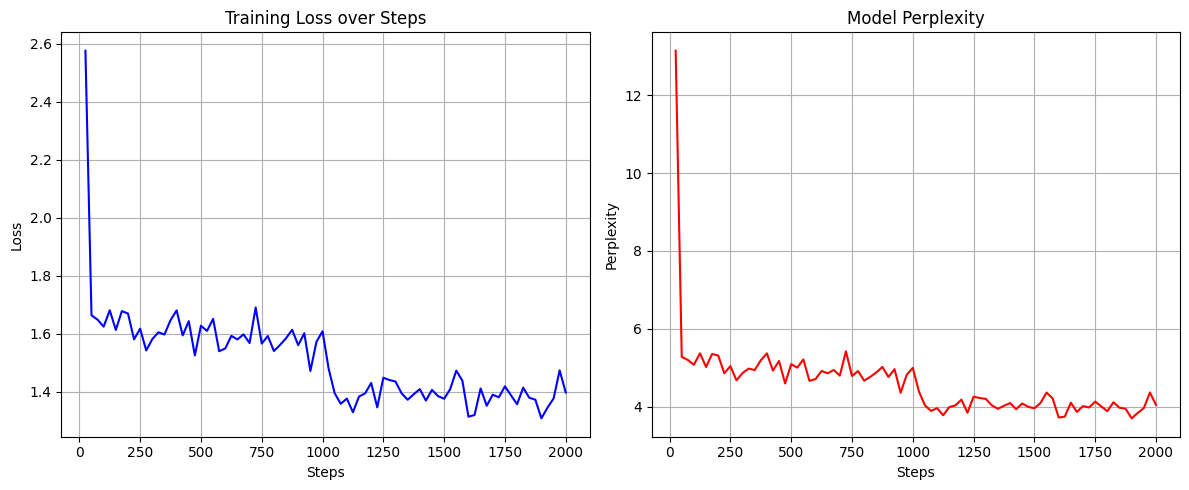

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Extract stats from trainer
history = trainer.state.log_history
df = pd.DataFrame(history)

# Filter for rows that contain 'loss'
df_loss = df[df['loss'].notna()]

# Calculate Perplexity: e^(loss)
df_loss['perplexity'] = np.exp(df_loss['loss'])

# Plotting
plt.figure(figsize=(12, 5))

# Subplot 1: Training Loss
plt.subplot(1, 2, 1)
plt.plot(df_loss['step'], df_loss['loss'], color='blue', label='Training Loss')
plt.title('Training Loss over Steps')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.grid(True)

# Subplot 2: Perplexity
plt.subplot(1, 2, 2)
plt.plot(df_loss['step'], df_loss['perplexity'], color='red', label='Perplexity')
plt.title('Model Perplexity')
plt.xlabel('Steps')
plt.ylabel('Perplexity')
plt.grid(True)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/training_metrics.png")
plt.show()

In [ ]:
from huggingface_hub import login

# Use your existing Write token here
MY_TOKEN = "hf"

# This logs you in silently and correctly
login(token=MY_TOKEN, add_to_git_credential=True)

# Now run the push command
repo_id = "J-Aamir/Fin-Qwen-7B-LoRA"
model.push_to_hub(repo_id, private=False)
tokenizer.push_to_hub(repo_id, private=False)

print(f"🚀 Success! View your model at: https://huggingface.co/{repo_id}")

README.md:   0%|          | 0.00/561 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          | 49.4kB /  162MB            

Saved model to https://huggingface.co/J-Aamir/Fin-Qwen-7B-LoRA


Unsloth: Restored added_tokens_decoder metadata in /tmp/tmpfqwlv5pp/tokenizer_config.json.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpfqwlv5pp/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

🚀 Success! View your model at: https://huggingface.co/J-Aamir/Fin-Qwen-7B-LoRA
